# FF++ C23 reusable frame extraction

This notebook performs only the expensive, one-time data preparation stage:

1. Reads the FF++ C23 video metadata.
2. Aligns each supported manipulation with its target original video.
3. Creates a shared 90/10 split at the original-video group level.
4. Extracts up to 100 aligned frames per video.
5. Saves portable relative image paths and complete metadata.

The output directory is designed to be attached directly to the separate training notebook as a Kaggle notebook output or Kaggle dataset.


## 1. Environment setup

In [1]:
from multiprocessing import cpu_count
print(f"Number of Logical CPU cores: {cpu_count()}")

Number of Logical CPU cores: 48


In [2]:
import os
import sys
import platform
import subprocess
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("Python:", sys.version)
print("Platform:", platform.platform())
print("\nGPU:")
subprocess.run(["nvidia-smi"], check=False)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35

GPU:
Wed Aug  5 03:23:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                           

CompletedProcess(args=['nvidia-smi'], returncode=0)

In [3]:
import shutil
import subprocess
from pathlib import Path
WORKING_DIR = Path("/kaggle/working")

In [4]:
import gc
import io
import json
import math
import random
import re
import hashlib
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Optional
import shutil
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TVF

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)

Device: cuda:0
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
PyTorch: 2.10.0+cu128


## 2. Configuration

In [5]:
from pathlib import Path

DATASET_OUTPUT_ROOT = Path(
    "/kaggle/working/ffpp_c23_extracted_dataset"
)

IMAGE_ROOT = DATASET_OUTPUT_ROOT / "images"
METADATA_ROOT = DATASET_OUTPUT_ROOT / "metadata"
SANITY_PLOT_ROOT = DATASET_OUTPUT_ROOT / "sanity_plots"

for directory in [
    DATASET_OUTPUT_ROOT,
    IMAGE_ROOT,
    METADATA_ROOT,
    SANITY_PLOT_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

In [6]:
FFPP_ROOT = Path("/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23")
CSV_DIR = FFPP_ROOT / "csv"

REAL_METHOD = "original"
FAKE_METHODS = [
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures",
]
STANDARD_ALIGNED_METHODS = FAKE_METHODS.copy()
ALL_METHODS = [REAL_METHOD] + FAKE_METHODS

CSV_FILES = {
    method: CSV_DIR / f"{method}.csv"
    for method in ALL_METHODS
}

# This whole directory is the reusable output contract.
DATASET_OUTPUT_ROOT = WORKING_DIR / "ffpp_c23_extracted_dataset"
IMAGE_ROOT = DATASET_OUTPUT_ROOT / "images"
METADATA_ROOT = DATASET_OUTPUT_ROOT / "metadata"
SANITY_PLOT_ROOT = DATASET_OUTPUT_ROOT / "sanity_plots"
PLOT_ROOT = SANITY_PLOT_ROOT

for folder in [
    IMAGE_ROOT,
    METADATA_ROOT,
    SANITY_PLOT_ROOT,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Frame dataset
FRAMES_PER_VIDEO = 100
FRAME_START_FRACTION = 0.05
FRAME_END_FRACTION = 0.95
SAVED_IMAGE_SIZE = 256
JPEG_QUALITY = 90
EXTRACTION_WORKERS = min(24, os.cpu_count() or 2)
REUSE_EXISTING_FRAMES = True

# Use a small integer for a pilot; None processes all videos.
MAX_VIDEOS_PER_METHOD = None

# Shared video-group split
TRAIN_FRACTION = 0.90
RANDOM_SEED = 42

# Sanity gallery
N_SANITY_GROUPS = 10
SANITY_FRAME_SLOT = FRAMES_PER_VIDEO // 2

print("FF++ source root:", FFPP_ROOT)
print("Reusable dataset output:", DATASET_OUTPUT_ROOT)
print("Methods:", ALL_METHODS)


FF++ source root: /kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23
Reusable dataset output: /kaggle/working/ffpp_c23_extracted_dataset
Methods: ['original', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']


In [7]:
usage = shutil.disk_usage(WORKING_DIR)
print(f"Free /kaggle/working: {usage.free / 1024**3:.2f} GB")
planned_videos = (1 + len(FAKE_METHODS)) * (MAX_VIDEOS_PER_METHOD or 1000)
planned_images = planned_videos * FRAMES_PER_VIDEO
print(f"Planned maximum videos: {planned_videos:,}")
print(f"Planned maximum images: {planned_images:,}")
print(
    "The notebook stores 256×256 JPEGs rather than 1080p frames. "
    "Run a small pilot first when disk quota is uncertain."
)

Free /kaggle/working: 19.50 GB
Planned maximum videos: 6,000
Planned maximum images: 600,000
The notebook stores 256×256 JPEGs rather than 1080p frames. Run a small pilot first when disk quota is uncertain.


## 3. Read and resolve CSV metadata

In [8]:
def normalize_column_name(name: str) -> str:
    normalized = re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower())
    return normalized.strip("_")

all_mp4 = [path for path in FFPP_ROOT.rglob("*.mp4") if path.is_file()]
relative_lookup = {
    path.relative_to(FFPP_ROOT).as_posix(): path
    for path in all_mp4
}
basename_lookup = {}
for path in all_mp4:
    basename_lookup.setdefault(path.name, []).append(path)

def resolve_video_path(value: str) -> Optional[Path]:
    relative_value = str(value).strip().replace("\\", "/").lstrip("/")
    root_prefix = f"{FFPP_ROOT.name}/"
    if relative_value.startswith(root_prefix):
        relative_value = relative_value[len(root_prefix):]

    if relative_value in relative_lookup:
        return relative_lookup[relative_value]

    candidate = FFPP_ROOT / relative_value
    if candidate.exists():
        return candidate

    matches = basename_lookup.get(Path(relative_value).name, [])
    if len(matches) == 1:
        return matches[0]
    return None

tables = []
for method, csv_path in CSV_FILES.items():
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV: {csv_path}")

    table = pd.read_csv(csv_path)
    table = table.loc[
        :, ~table.columns.astype(str).str.startswith("Unnamed")
    ].copy()
    table.columns = [normalize_column_name(column) for column in table.columns]

    required = {"file_path", "label"}
    missing = required - set(table.columns)
    if missing:
        raise KeyError(
            f"{csv_path.name} is missing {sorted(missing)}; "
            f"columns={table.columns.tolist()}"
        )

    table["method"] = method
    table["label_int"] = 0 if method == REAL_METHOD else 1
    table["video_path"] = table["file_path"].map(resolve_video_path)

    unresolved = table["video_path"].isna()
    if unresolved.any():
        examples = table.loc[unresolved, "file_path"].head(10).tolist()
        raise FileNotFoundError(
            f"Could not resolve {unresolved.sum()} rows in {csv_path.name}: "
            f"{examples}"
        )

    table["video_path"] = table["video_path"].astype(str)
    if "frame_count" in table:
        table["frame_count"] = pd.to_numeric(
            table["frame_count"], errors="coerce"
        )
    tables.append(table)

raw_video_manifest = pd.concat(tables, ignore_index=True)

display(
    raw_video_manifest.groupby(["method", "label_int"])
    .size().rename("video_count").reset_index()
)
display(raw_video_manifest.head())

,method,label_int,video_count
0,Deepfakes,1,1000
1,Face2Face,1,1000
2,FaceShifter,1,1000
3,FaceSwap,1,1000
4,NeuralTextures,1,1000
5,original,0,1000


,file_path,label,frame_count,width,height,codec,file_size_mb,method,label_int,video_path
0,original/000.mp4,REAL,396,640,480,h264,0.85,original,0,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...
1,original/001.mp4,REAL,460,1280,720,h264,2.78,original,0,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...
2,original/002.mp4,REAL,693,1280,720,h264,2.02,original,0,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...
3,original/003.mp4,REAL,303,640,480,h264,0.58,original,0,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...
4,original/004.mp4,REAL,309,1280,720,h264,1.20,original,0,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...


## 4. Build aligned pairs and the shared 90/10 split

In [9]:
original_rows = (
    raw_video_manifest[raw_video_manifest["method"] == REAL_METHOD]
    .copy()
    .sort_values("video_path")
    .reset_index(drop=True)
)
original_rows["original_id"] = original_rows["video_path"].map(
    lambda path: Path(path).stem
)

original_lookup = {
    row.original_id: row
    for row in original_rows.itertuples(index=False)
}
if len(original_lookup) != len(original_rows):
    raise ValueError("Original IDs are not unique.")

def parse_target_id(path: str) -> Optional[str]:
    match = re.match(r"^(\d{3})_", Path(path).stem)
    return match.group(1) if match else None

pair_rows = []

for method in STANDARD_ALIGNED_METHODS:
    method_rows = (
        raw_video_manifest[raw_video_manifest["method"] == method]
        .copy()
        .sort_values("video_path")
        .reset_index(drop=True)
    )
    if MAX_VIDEOS_PER_METHOD is not None:
        method_rows = method_rows.head(MAX_VIDEOS_PER_METHOD)

    for fake_row in method_rows.itertuples(index=False):
        target_id = parse_target_id(fake_row.video_path)
        if target_id not in original_lookup:
            raise ValueError(
                f"Cannot map {method} file to original: {fake_row.video_path}"
            )
        real_row = original_lookup[target_id]
        pair_rows.append({
            "method": method,
            "fake_video_path": fake_row.video_path,
            "fake_relative_path": fake_row.file_path,
            "fake_frame_count": getattr(fake_row, "frame_count", np.nan),
            "real_video_path": real_row.video_path,
            "real_relative_path": real_row.file_path,
            "real_frame_count": getattr(real_row, "frame_count", np.nan),
            "pair_group_id": target_id,
            "target_original_id": target_id,
            "alignment_type": "target_original_aligned",
        })

pair_manifest = pd.DataFrame(pair_rows)
used_groups = sorted(pair_manifest["pair_group_id"].unique())

if MAX_VIDEOS_PER_METHOD is not None:
    used_groups = used_groups[:MAX_VIDEOS_PER_METHOD]
    pair_manifest = pair_manifest[
        pair_manifest["pair_group_id"].isin(used_groups)
    ].copy()

train_groups, val_groups = train_test_split(
    used_groups,
    train_size=TRAIN_FRACTION,
    random_state=RANDOM_SEED,
    shuffle=True,
)
train_groups = set(train_groups)
val_groups = set(val_groups)

pair_manifest["data_split"] = pair_manifest["pair_group_id"].map(
    lambda group: "train" if group in train_groups else "val"
)

split_map = pd.DataFrame({
    "pair_group_id": used_groups,
    "data_split": [
        "train" if group in train_groups else "val"
        for group in used_groups
    ],
})

pair_manifest.to_csv(
    METADATA_ROOT / "ffpp_video_pair_manifest.csv",
    index=False,
)
split_map.to_csv(
    METADATA_ROOT / "ffpp_train_val_groups.csv",
    index=False,
)

assert train_groups.isdisjoint(val_groups)

display(
    pair_manifest.groupby(
        ["method", "alignment_type", "data_split"]
    ).size().rename("video_pairs").reset_index()
)
print(
    f"Groups: {len(train_groups)} train / {len(val_groups)} validation"
)


,method,alignment_type,data_split,video_pairs
0,Deepfakes,target_original_aligned,train,900
1,Deepfakes,target_original_aligned,val,100
2,Face2Face,target_original_aligned,train,900
3,Face2Face,target_original_aligned,val,100
4,FaceShifter,target_original_aligned,train,900
5,FaceShifter,target_original_aligned,val,100
6,FaceSwap,target_original_aligned,train,900
7,FaceSwap,target_original_aligned,val,100
8,NeuralTextures,target_original_aligned,train,900
9,NeuralTextures,target_original_aligned,val,100


Groups: 900 train / 100 validation


In [10]:
standard_rows = pair_manifest[
    pair_manifest["method"].isin(STANDARD_ALIGNED_METHODS)
]
assert (
    standard_rows["target_original_id"]
    == standard_rows["pair_group_id"]
).all()

assert (
    pair_manifest.groupby(["method", "fake_video_path"]).size().max()
    == 1
)

print("Standard-method target mapping passed.")
# print(
#     "DFD unpaired fallback rows:",
#     (pair_manifest["alignment_type"] == "unpaired_original_fallback").sum(),
# )
display(pair_manifest.sample(min(10, len(pair_manifest)), random_state=RANDOM_SEED))

Standard-method target mapping passed.


,method,fake_video_path,fake_relative_path,fake_frame_count,real_video_path,real_relative_path,real_frame_count,pair_group_id,target_original_id,alignment_type,data_split
1501,Face2Face,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Face2Face/501_326.mp4,914,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/501.mp4,522,501,501,target_original_aligned,train
2586,FaceShifter,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,FaceShifter/586_223.mp4,379,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/586.mp4,379,586,586,target_original_aligned,train
2653,FaceShifter,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,FaceShifter/653_601.mp4,731,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/653.mp4,731,653,653,target_original_aligned,train
1055,Face2Face,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Face2Face/055_147.mp4,667,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/055.mp4,394,055,055,target_original_aligned,train
705,Deepfakes,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Deepfakes/705_707.mp4,473,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/705.mp4,473,705,705,target_original_aligned,train
106,Deepfakes,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Deepfakes/106_198.mp4,356,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/106.mp4,356,106,106,target_original_aligned,train
589,Deepfakes,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Deepfakes/589_565.mp4,686,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/589.mp4,686,589,589,target_original_aligned,val
2468,FaceShifter,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,FaceShifter/468_470.mp4,597,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/468.mp4,597,468,468,target_original_aligned,train
2413,FaceShifter,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,FaceShifter/413_372.mp4,379,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/413.mp4,379,413,413,target_original_aligned,train
1600,Face2Face,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,Face2Face/600_505.mp4,543,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,original/600.mp4,388,600,600,target_original_aligned,train


## 5. Extract the reusable frame dataset

In [11]:
def stable_video_id(relative_path: str) -> str:
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", Path(relative_path).stem)
    digest = hashlib.sha1(relative_path.encode("utf-8")).hexdigest()[:10]
    return f"{stem[:90]}__{digest}"

def get_total_frames(video_path: Path, metadata_count=np.nan) -> int:
    if pd.notna(metadata_count) and int(metadata_count) > 0:
        return int(metadata_count)

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return 0
    total = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    capture.release()
    return total

def choose_slots(total_frames: int):
    if total_frames <= 0:
        return []

    count = min(FRAMES_PER_VIDEO, total_frames)
    positions = np.linspace(
        FRAME_START_FRACTION,
        FRAME_END_FRACTION,
        num=count,
    )
    frame_indices = np.rint(
        positions * (total_frames - 1)
    ).astype(int)

    output = []
    seen = set()
    for slot, (position, frame_index) in enumerate(
        zip(positions, frame_indices)
    ):
        frame_index = int(frame_index)
        if frame_index in seen:
            continue
        seen.add(frame_index)
        output.append((slot, float(position), frame_index))
    return output

def center_square_resize(frame_bgr: np.ndarray) -> np.ndarray:
    height, width = frame_bgr.shape[:2]
    side = min(height, width)
    top = (height - side) // 2
    left = (width - side) // 2
    crop = frame_bgr[top:top + side, left:left + side]
    return cv2.resize(
        crop,
        (SAVED_IMAGE_SIZE, SAVED_IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )

def extract_video_task(task: dict):
    method = task["method"]
    video_path = Path(task["video_path"])
    video_id = stable_video_id(task["relative_path"])
    output_dir = IMAGE_ROOT / method / video_id
    output_dir.mkdir(parents=True, exist_ok=True)

    total_frames = get_total_frames(
        video_path,
        task.get("metadata_frame_count", np.nan),
    )
    selections = choose_slots(total_frames)

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return [], [{
            "method": method,
            "video_path": str(video_path),
            "error": "could_not_open_video",
        }]

    records = []
    errors = []

    for frame_slot, normalized_position, frame_index in selections:
        output_path = (
            output_dir
            / f"slot_{frame_slot:03d}_frame_{frame_index:06d}.jpg"
        )

        if output_path.exists() and REUSE_EXISTING_FRAMES:
            status = "existing"
        else:
            capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
            ok, frame = capture.read()
            if not ok or frame is None:
                errors.append({
                    "method": method,
                    "video_path": str(video_path),
                    "frame_slot": frame_slot,
                    "frame_index": frame_index,
                    "error": "decode_failed",
                })
                continue

            frame = center_square_resize(frame)
            ok = cv2.imwrite(
                str(output_path),
                frame,
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY],
            )
            if not ok:
                errors.append({
                    "method": method,
                    "video_path": str(video_path),
                    "frame_slot": frame_slot,
                    "frame_index": frame_index,
                    "error": "jpeg_write_failed",
                })
                continue
            status = "extracted"

        records.append({
            "method": method,
            "label": task["label"],
            "data_split": task["data_split"],
            "pair_group_id": task["pair_group_id"],
            "alignment_type": task["alignment_type"],
            "video_id": video_id,
            "source_relative_path": task["relative_path"],
            "source_video_path": str(video_path),
            "source_total_frames": total_frames,
            "frame_slot": frame_slot,
            "normalized_position": normalized_position,
            "source_frame_index": frame_index,
            "relative_image_path": output_path.relative_to(
                DATASET_OUTPUT_ROOT
            ).as_posix(),
            "image_path": str(output_path),
            "status": status,
        })

    capture.release()
    return records, errors

In [12]:
tasks = []

selected_originals = original_rows[
    original_rows["original_id"].isin(used_groups)
].copy()
selected_originals["data_split"] = selected_originals["original_id"].map(
    lambda group: "train" if group in train_groups else "val"
)

for row in selected_originals.itertuples(index=False):
    tasks.append({
        "method": REAL_METHOD,
        "label": 0,
        "data_split": row.data_split,
        "pair_group_id": row.original_id,
        "alignment_type": "authentic_original",
        "video_path": row.video_path,
        "relative_path": row.file_path,
        "metadata_frame_count": getattr(row, "frame_count", np.nan),
    })

for row in pair_manifest.itertuples(index=False):
    tasks.append({
        "method": row.method,
        "label": 1,
        "data_split": row.data_split,
        "pair_group_id": row.pair_group_id,
        "alignment_type": row.alignment_type,
        "video_path": row.fake_video_path,
        "relative_path": row.fake_relative_path,
        "metadata_frame_count": row.fake_frame_count,
    })

task_manifest = pd.DataFrame(tasks).drop_duplicates(
    subset=["method", "video_path"]
)
task_manifest.to_csv(
    METADATA_ROOT / "ffpp_extraction_task_manifest.csv",
    index=False,
)

display(
    task_manifest.groupby(
        ["method", "label", "data_split"]
    ).size().rename("videos").reset_index()
)
print("Total extraction tasks:", len(task_manifest))

,method,label,data_split,videos
0,Deepfakes,1,train,900
1,Deepfakes,1,val,100
2,Face2Face,1,train,900
3,Face2Face,1,val,100
4,FaceShifter,1,train,900
5,FaceShifter,1,val,100
6,FaceSwap,1,train,900
7,FaceSwap,1,val,100
8,NeuralTextures,1,train,900
9,NeuralTextures,1,val,100


Total extraction tasks: 6000


In [13]:
all_frame_records = []
all_extraction_errors = []

task_dicts = task_manifest.to_dict("records")

with ThreadPoolExecutor(max_workers=EXTRACTION_WORKERS) as executor:
    future_to_task = {
        executor.submit(extract_video_task, task): task
        for task in task_dicts
    }

    for future in tqdm(
        as_completed(future_to_task),
        total=len(future_to_task),
        desc="Extracting videos",
    ):
        task = future_to_task[future]
        try:
            records, errors = future.result()
            all_frame_records.extend(records)
            all_extraction_errors.extend(errors)
        except Exception as exc:
            all_extraction_errors.append({
                "method": task["method"],
                "video_path": task["video_path"],
                "error": f"unhandled_exception: {exc}",
            })

frame_metadata = pd.DataFrame(all_frame_records)
if frame_metadata.empty:
    raise RuntimeError("No frames were extracted.")

frame_metadata = frame_metadata.sort_values(
    ["data_split", "method", "pair_group_id", "frame_slot"]
).reset_index(drop=True)
frame_metadata["feature_index"] = np.arange(
    len(frame_metadata), dtype=np.int64
)

FRAME_METADATA_CSV = METADATA_ROOT / "ffpp_frame_metadata.csv"
frame_metadata.to_csv(FRAME_METADATA_CSV, index=False)

if all_extraction_errors:
    pd.DataFrame(all_extraction_errors).to_csv(
        METADATA_ROOT / "ffpp_extraction_errors.csv",
        index=False,
    )

display(
    frame_metadata.groupby(
        ["method", "label", "data_split"]
    ).size().rename("frames").reset_index()
)
print("Metadata:", FRAME_METADATA_CSV)
print("Errors:", len(all_extraction_errors))

dataset_bytes = sum(
    path.stat().st_size
    for path in DATASET_OUTPUT_ROOT.rglob("*")
    if path.is_file()
)
print(f"Current dataset size: {dataset_bytes / 1024**3:.2f} GB")

Extracting videos:   0%|          | 0/6000 [00:00<?, ?it/s]

,method,label,data_split,frames
0,Deepfakes,1,train,90000
1,Deepfakes,1,val,10000
2,Face2Face,1,train,90000
3,Face2Face,1,val,10000
4,FaceShifter,1,train,90000
5,FaceShifter,1,val,10000
6,FaceSwap,1,train,90000
7,FaceSwap,1,val,10000
8,NeuralTextures,1,train,90000
9,NeuralTextures,1,val,10000


Metadata: /kaggle/working/ffpp_c23_extracted_dataset/metadata/ffpp_frame_metadata.csv
Errors: 0
Current dataset size: 9.77 GB


In [14]:
frame_metadata

,method,label,data_split,pair_group_id,alignment_type,video_id,source_relative_path,source_video_path,source_total_frames,frame_slot,normalized_position,source_frame_index,relative_image_path,image_path,status,feature_index
0,Deepfakes,1,train,000,target_original_aligned,000_003__7904db9a43,Deepfakes/000_003.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,396,0,0.050000,20,images/Deepfakes/000_003__7904db9a43/slot_000_...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,0
1,Deepfakes,1,train,000,target_original_aligned,000_003__7904db9a43,Deepfakes/000_003.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,396,1,0.059091,23,images/Deepfakes/000_003__7904db9a43/slot_001_...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,1
2,Deepfakes,1,train,000,target_original_aligned,000_003__7904db9a43,Deepfakes/000_003.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,396,2,0.068182,27,images/Deepfakes/000_003__7904db9a43/slot_002_...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,2
3,Deepfakes,1,train,000,target_original_aligned,000_003__7904db9a43,Deepfakes/000_003.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,396,3,0.077273,31,images/Deepfakes/000_003__7904db9a43/slot_003_...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,3
4,Deepfakes,1,train,000,target_original_aligned,000_003__7904db9a43,Deepfakes/000_003.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,396,4,0.086364,34,images/Deepfakes/000_003__7904db9a43/slot_004_...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,original,0,val,998,authentic_original,998__4c6f291a64,original/998.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,344,95,0.913636,313,images/original/998__4c6f291a64/slot_095_frame...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,599995
599996,original,0,val,998,authentic_original,998__4c6f291a64,original/998.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,344,96,0.922727,316,images/original/998__4c6f291a64/slot_096_frame...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,599996
599997,original,0,val,998,authentic_original,998__4c6f291a64,original/998.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,344,97,0.931818,320,images/original/998__4c6f291a64/slot_097_frame...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,599997
599998,original,0,val,998,authentic_original,998__4c6f291a64,original/998.mp4,/kaggle/input/datasets/xdxd003/ff-c23/FaceFore...,344,98,0.940909,323,images/original/998__4c6f291a64/slot_098_frame...,/kaggle/working/ffpp_c23_extracted_dataset/ima...,extracted,599998


In [15]:
# Leakage and slot alignment checks.

assert (
    frame_metadata.groupby("pair_group_id")["data_split"].nunique().max()
    == 1
), "A pair group leaked across train/validation."

real_slot_map = (
    frame_metadata[frame_metadata["method"] == REAL_METHOD]
    .groupby("pair_group_id")["frame_slot"]
    .apply(set)
    .to_dict()
)

coverage = []
for method in FAKE_METHODS:
    method_rows = frame_metadata[frame_metadata["method"] == method]
    for group_id, group in method_rows.groupby("pair_group_id"):
        shared_slots = len(
            set(group["frame_slot"]) & real_slot_map.get(group_id, set())
        )
        coverage.append({
            "method": method,
            "pair_group_id": group_id,
            "fake_frames": len(group),
            "shared_frame_slots_with_real": shared_slots,
        })

alignment_coverage = pd.DataFrame(coverage)
alignment_coverage.to_csv(
    METADATA_ROOT / "ffpp_alignment_coverage.csv",
    index=False,
)

display(
    alignment_coverage.groupby("method")
    .agg(
        groups=("pair_group_id", "nunique"),
        mean_fake_frames=("fake_frames", "mean"),
        mean_shared_slots=("shared_frame_slots_with_real", "mean"),
        min_shared_slots=("shared_frame_slots_with_real", "min"),
    )
    .reset_index()
    .round(2)
)

,method,groups,mean_fake_frames,mean_shared_slots,min_shared_slots
0,Deepfakes,1000,100.0,100.0,100
1,Face2Face,1000,100.0,100.0,100
2,FaceShifter,1000,100.0,100.0,100
3,FaceSwap,1000,100.0,100.0,100
4,NeuralTextures,1000,100.0,100.0,100


## 6. Sanity check: 10 original examples versus every fake method

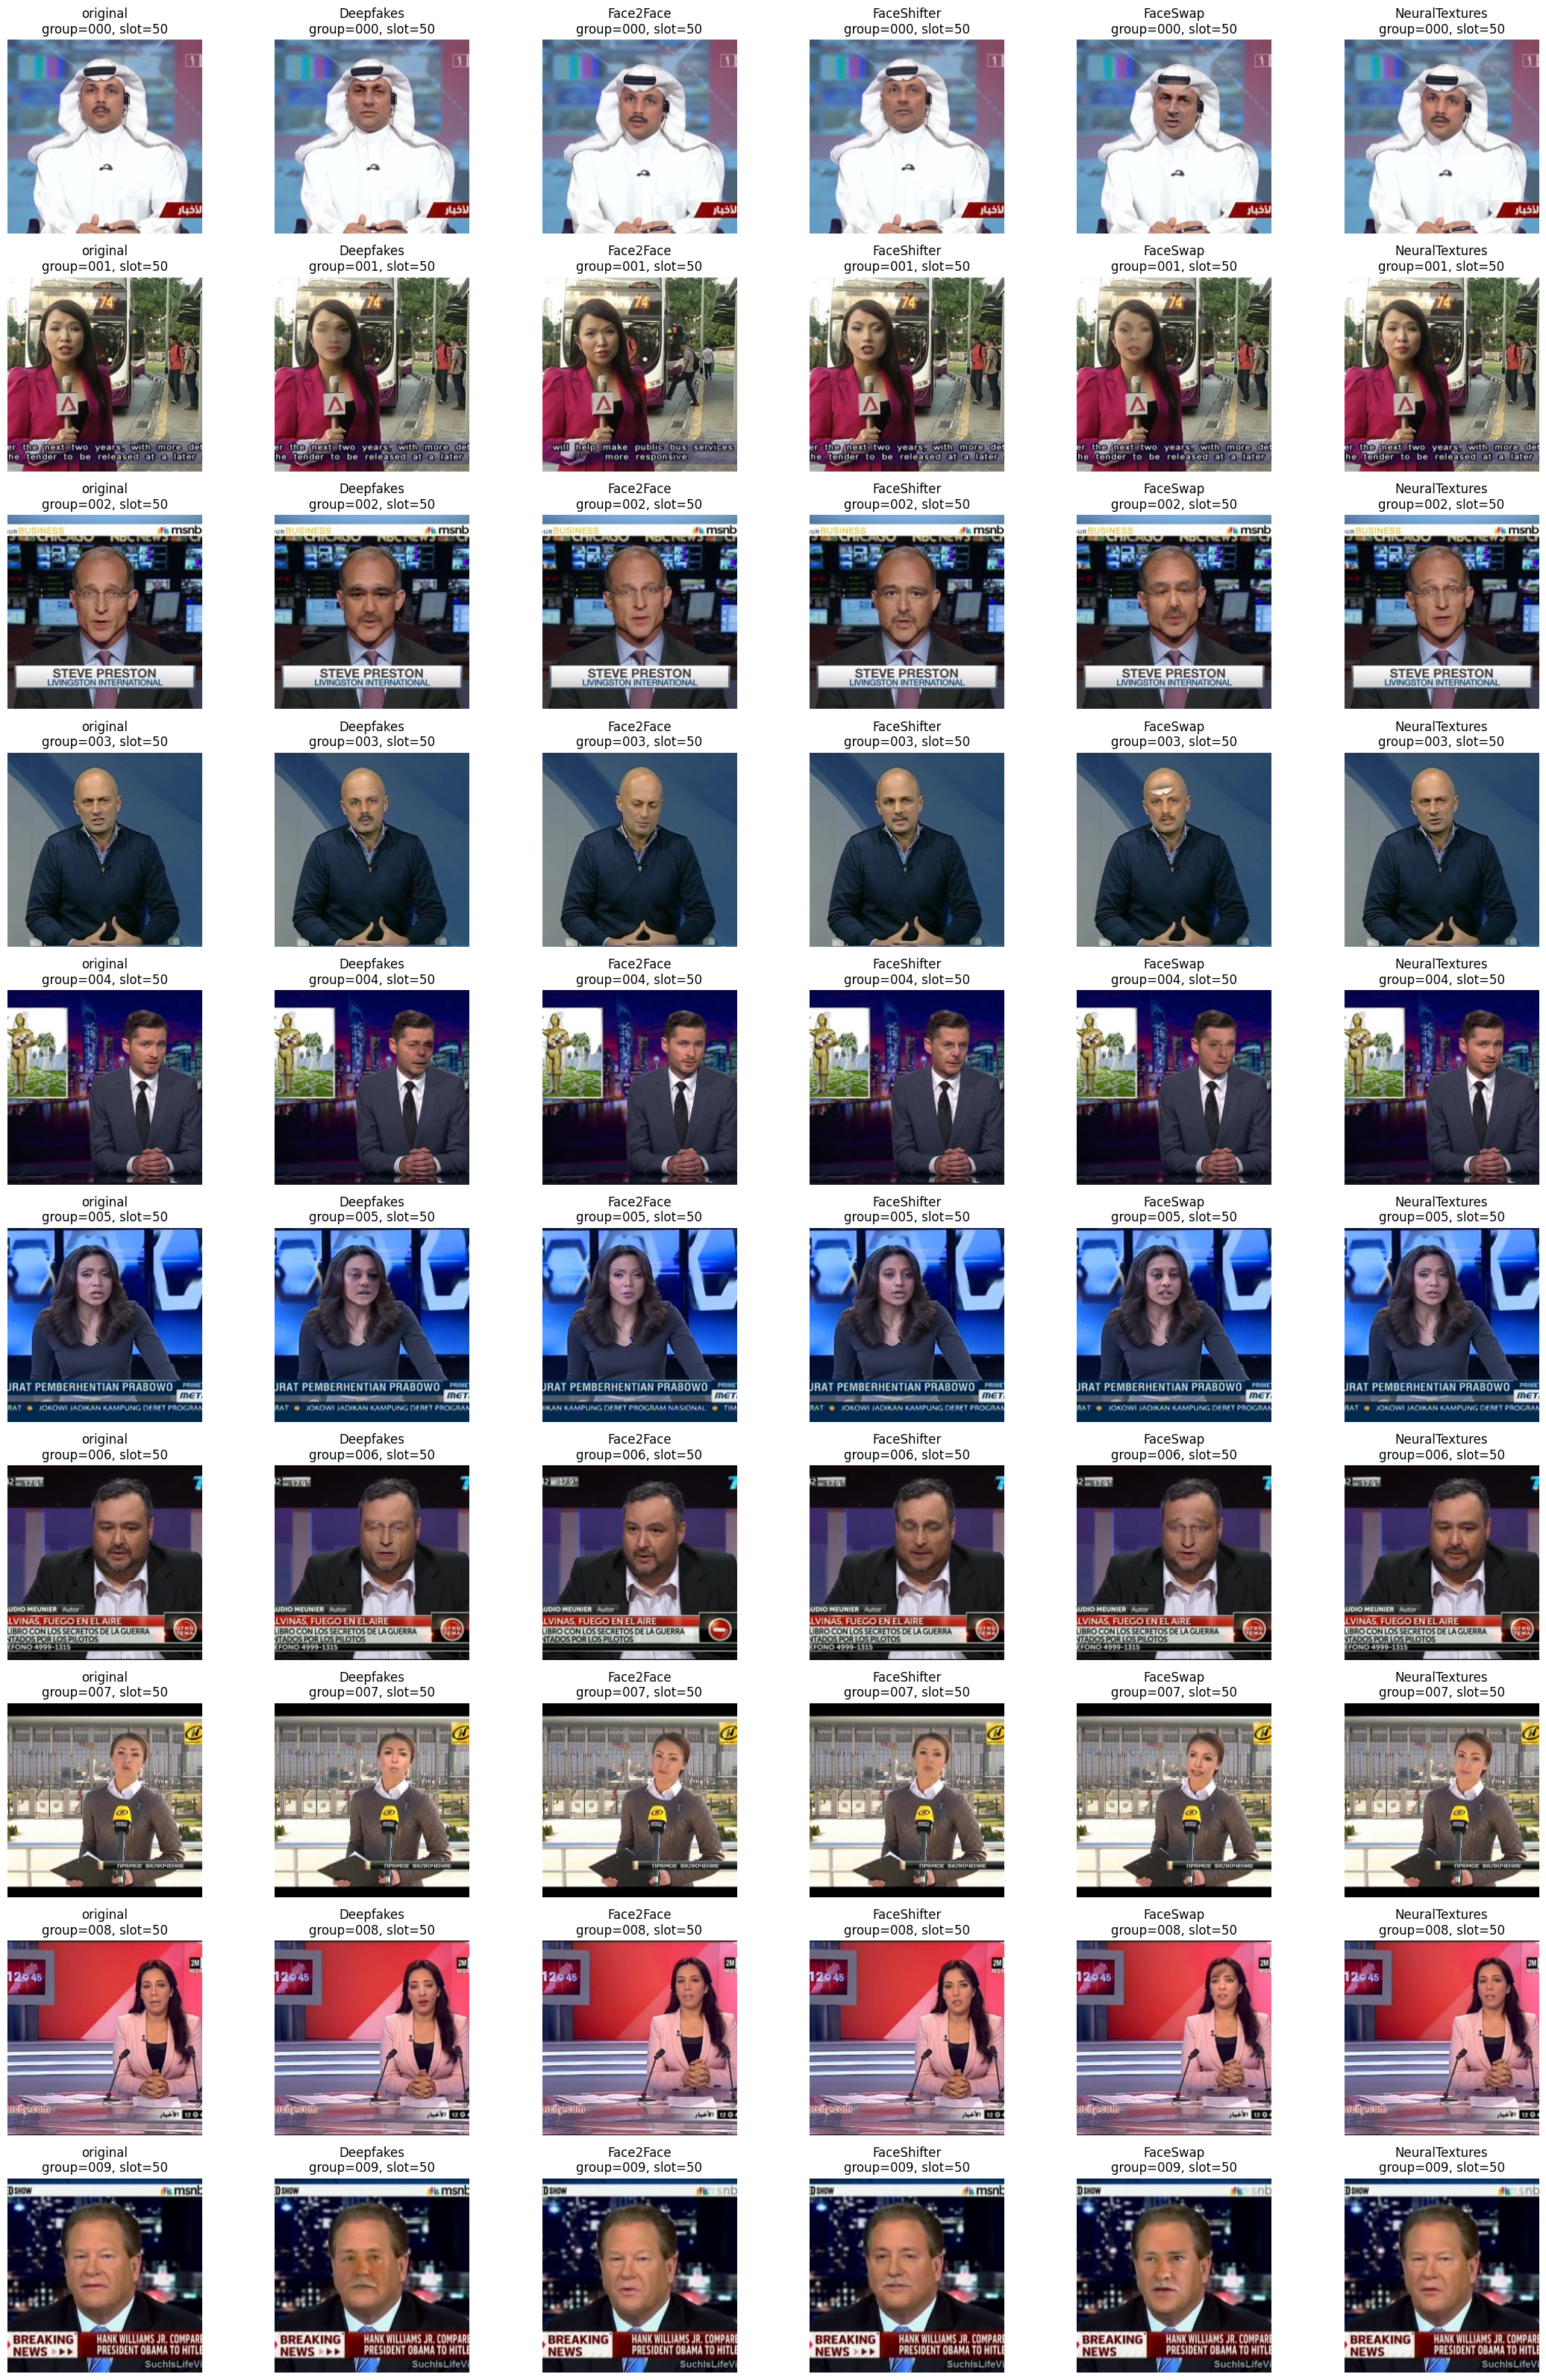

Saved: /kaggle/working/ffpp_c23_extracted_dataset/sanity_plots/ten_original_vs_all_fake_methods.png


In [16]:
def load_rgb(path: str):
    with Image.open(path) as image:
        return image.convert("RGB").copy()

sanity_groups = sorted(
    frame_metadata["pair_group_id"].unique()
)[:N_SANITY_GROUPS]
column_methods = [REAL_METHOD] + FAKE_METHODS

figure, axes = plt.subplots(
    len(sanity_groups),
    len(column_methods),
    figsize=(22, 3.2 * len(sanity_groups)),
)
if len(sanity_groups) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, group_id in enumerate(sanity_groups):
    for column_index, method in enumerate(column_methods):
        candidates = frame_metadata[
            (frame_metadata["pair_group_id"] == group_id)
            & (frame_metadata["method"] == method)
        ].copy()

        axis = axes[row_index, column_index]
        if candidates.empty:
            axis.axis("off")
            axis.set_title(f"{method}\nmissing")
            continue

        candidates["slot_distance"] = (
            candidates["frame_slot"] - SANITY_FRAME_SLOT
        ).abs()
        sample = candidates.sort_values("slot_distance").iloc[0]

        axis.imshow(load_rgb(sample["image_path"]))
        method_title = method
        if method == "DeepFakeDetection":
            method_title += "\n(unpaired fallback)"
        axis.set_title(
            f"{method_title}\ngroup={group_id}, slot={sample['frame_slot']}"
        )
        axis.axis("off")

plt.tight_layout()
SANITY_PLOT_PATH = PLOT_ROOT / "ten_original_vs_all_fake_methods.png"
plt.savefig(SANITY_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", SANITY_PLOT_PATH)

## 7. Save dataset documentation

In [17]:
dataset_summary = {
    "dataset_name": "FF++ C23 extracted frames for UniversalFakeDetect",
    "source": "Kaggle xdxd003/ff-c23",
    "ffpp_root": str(FFPP_ROOT),
    "frames_per_video_max": FRAMES_PER_VIDEO,
    "saved_image_size": SAVED_IMAGE_SIZE,
    "jpeg_quality": JPEG_QUALITY,
    "train_fraction_by_video_group": TRAIN_FRACTION,
    "random_seed": RANDOM_SEED,
    "methods": ALL_METHODS,
    "excluded_methods": ["DeepFakeDetection"],
    "videos": int(len(task_manifest)),
    "frames": int(len(frame_metadata)),
    "portable_path_column": "relative_image_path",
}

with (METADATA_ROOT / "dataset_summary.json").open("w") as file:
    json.dump(dataset_summary, file, indent=2)

readme_lines = [
    "# FF++ C23 frame dataset for UniversalFakeDetect",
    "",
    f"- Maximum frames per video: {FRAMES_PER_VIDEO}",
    f"- Stored image size: {SAVED_IMAGE_SIZE}x{SAVED_IMAGE_SIZE}",
    f"- JPEG quality: {JPEG_QUALITY}",
    "- Split: 90/10 at pair-group/video level",
    "- Main metadata: metadata/ffpp_frame_metadata.csv",
    "- Pair metadata: metadata/ffpp_video_pair_manifest.csv",
    "- Portable image paths are stored in relative_image_path.",
    "- DeepFakeDetection is intentionally excluded.",
    "",
    "Attach the entire ffpp_c23_extracted_dataset directory to the",
    "training notebook through Kaggle Add Input.",
]
(METADATA_ROOT / "README.md").write_text("\n".join(readme_lines))

print("Reusable dataset root:")
print(DATASET_OUTPUT_ROOT)
print("Use Kaggle Save Version with notebook outputs enabled.")


Reusable dataset root:
/kaggle/working/ffpp_c23_extracted_dataset
Use Kaggle Save Version with notebook outputs enabled.


## 8. Final output-contract validation

This verifies that the saved metadata can reconstruct every image from the reusable dataset root. The training notebook relies on this exact contract.


In [18]:
required_columns = {
    "method",
    "label",
    "data_split",
    "pair_group_id",
    "relative_image_path",
    "video_id",
    "frame_slot",
}
missing_columns = required_columns - set(frame_metadata.columns)
if missing_columns:
    raise KeyError(f"Missing required metadata columns: {sorted(missing_columns)}")

resolved_paths = frame_metadata["relative_image_path"].map(
    lambda relative_path: DATASET_OUTPUT_ROOT / str(relative_path)
)
missing_mask = ~resolved_paths.map(Path.exists)

print(f"Metadata rows: {len(frame_metadata):,}")
print(f"Resolved image files: {(~missing_mask).sum():,}")
print(f"Missing image files: {missing_mask.sum():,}")

if missing_mask.any():
    display(frame_metadata.loc[missing_mask, ["relative_image_path"]].head(10))
    raise FileNotFoundError("Some metadata image paths cannot be resolved.")

duplicate_paths = frame_metadata["relative_image_path"].duplicated().sum()
if duplicate_paths:
    raise RuntimeError(f"Duplicate relative image paths: {duplicate_paths}")

group_leakage = (
    frame_metadata.groupby("pair_group_id")["data_split"].nunique() > 1
).sum()
if group_leakage:
    raise RuntimeError(f"Pair-group leakage detected in {group_leakage} groups.")

print("\nOutput contract passed.")
print("Dataset to publish/attach:", DATASET_OUTPUT_ROOT)
print("Main metadata:", METADATA_ROOT / "ffpp_frame_metadata.csv")


Metadata rows: 600,000
Resolved image files: 600,000
Missing image files: 0

Output contract passed.
Dataset to publish/attach: /kaggle/working/ffpp_c23_extracted_dataset
Main metadata: /kaggle/working/ffpp_c23_extracted_dataset/metadata/ffpp_frame_metadata.csv
